Generated data: x shape=(1000, 1), y_true shape=(1000, 1), y_noise shape=(1000, 1)


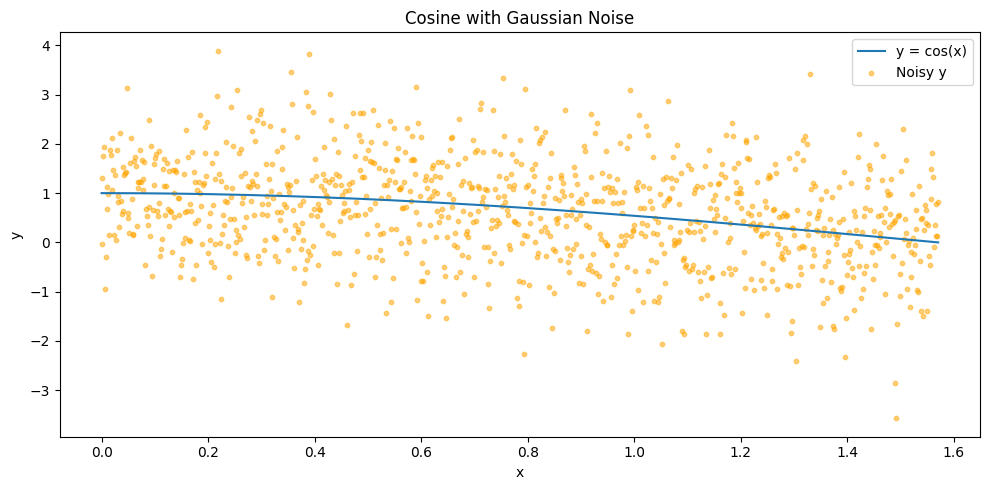

Saved plot to cosine_with_noise.png
Train size: 800, Validation size: 200
Training with batch size 10: 80 batches
Training with batch size 20: 40 batches

--- Forward Check (batch size=10) ---
Input batch shape: (10, 1)
W1 shape: (1, 5)
W2 shape: (5, 1)
ynoise (batch):
[ 1.2161  1.6316  0.526   1.3903 -0.2699 -0.2713 -1.4308  0.2202 -0.4567
 -1.0039]
ypred (batch):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Average MSE over batch: 0.980919

--- Forward Check (batch size=20) ---
Input batch shape: (20, 1)
W1 shape: (1, 5)
W2 shape: (5, 1)
ynoise (batch):
[ 1.2161  1.6316  0.526   1.3903 -0.2699 -0.2713 -1.4308  0.2202 -0.4567
 -1.0039  1.603  -0.9906  0.915  -0.4276  1.8688 -0.2009 -1.4699  2.9733
  0.571   0.6769]
ypred (batch):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Average MSE over batch: 1.484910


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def generate_data(n_points=1000, noise_std=1.0, seed=42):
    """
    Generate x in [0, 2pi], true y = cos(x), and noisy y with epsilon ~ N(0, noise_std^2)
    Returns arrays shaped (n_points, 1)
    """
    rng = np.random.default_rng(seed)
    x = np.linspace(0.0, 0.5 * np.pi, n_points).reshape(-1, 1)
    y_true = np.cos(x)
    eps = rng.normal(0.0, noise_std, size=(n_points, 1))
    y_noise = y_true + eps
    return x, y_true, y_noise


def plot_data(x, y_true, y_noise, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(x, y_true, label="y = cos(x)")
    plt.scatter(x, y_noise, s=10, alpha=0.5, color="orange", label="Noisy y")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Cosine with Gaussian Noise")
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
    # Show non-blocking to avoid hanging scripts in some environments
    try:
        plt.show(block=False)
    except Exception:
        pass
    plt.close()


def train_val_split(x, y, train_ratio=0.8, seed=42):
    """Shuffle and split into train/val sets."""
    rng = np.random.default_rng(seed)
    n = x.shape[0]
    idx = np.arange(n)
    rng.shuffle(idx)
    x_shuf = x[idx]
    y_shuf = y[idx]
    split_idx = int(train_ratio * n)
    x_train, y_train = x_shuf[:split_idx], y_shuf[:split_idx]
    x_val, y_val = x_shuf[split_idx:], y_shuf[split_idx:]
    return (x_train, y_train), (x_val, y_val)


def batch_iter(X, y, batch_size, shuffle=True, seed=123):
    n = X.shape[0]
    indices = np.arange(n)
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_idx = indices[start:end]
        yield X[batch_idx], y[batch_idx]


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def relu(z):
    return np.maximum(0.0, z)


def init_params(input_dim=1, hidden_dim=5, output_dim=1, seed=0):
    rng = np.random.default_rng(seed)
    # Xavier/He-like small init for stability in forward check
    W1 = rng.normal(0.0, 1.0 / np.sqrt(input_dim), size=(input_dim, hidden_dim))
    b1 = np.zeros((1, hidden_dim))
    W2 = rng.normal(0.0, 1.0 / np.sqrt(hidden_dim), size=(hidden_dim, output_dim))
    b2 = np.zeros((1, output_dim))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


def forward_batch(X, params):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]
    # Input -> Hidden (Sigmoid)
    Z1 = X @ W1 + b1  # (B, 1) @ (1, 5) => (B, 5)
    A1 = sigmoid(Z1)  # (B, 5)
    # Hidden -> Output (ReLU)
    Z2 = A1 @ W2 + b2  # (B, 5) @ (5, 1) => (B, 1)
    Y_hat = relu(Z2)   # (B, 1)
    return Y_hat


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def run_forward_check(batch_size, X_train, y_train, params, shuffle_seed=123):
    batches = list(batch_iter(X_train, y_train, batch_size=batch_size, shuffle=True, seed=shuffle_seed))
    Xb, yb = batches[0]
    y_pred = forward_batch(Xb, params)
    loss = mse(yb, y_pred)

    print(f"\n--- Forward Check (batch size={batch_size}) ---")
    print(f"Input batch shape: {Xb.shape}")
    print(f"W1 shape: {params['W1'].shape}")
    print(f"W2 shape: {params['W2'].shape}")
    print("ynoise (batch):")
    print(np.squeeze(yb))
    print("ypred (batch):")
    print(np.squeeze(y_pred))
    print(f"Average MSE over batch: {loss:.6f}")


def main():
    np.set_printoptions(precision=4, suppress=True)

    # 1) Data Preparation
    seed = 42
    x, y_true, y_noise = generate_data(n_points=1000, noise_std=1.0, seed=seed)
    print(f"Generated data: x shape={x.shape}, y_true shape={y_true.shape}, y_noise shape={y_noise.shape}")

    # Plot
    plot_path = "cosine_with_noise.png"
    plot_data(x, y_true, y_noise, save_path=plot_path)
    print(f"Saved plot to {plot_path}")

    # Split into train/validation
    (X_train, y_train), (X_val, y_val) = train_val_split(x, y_noise, train_ratio=0.8, seed=seed)
    print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")

    # Shuffle training and arrange into batches of size 10 and 20
    for bs in (10, 20):
        n_batches = int(np.ceil(X_train.shape[0] / bs))
        print(f"Training with batch size {bs}: {n_batches} batches")

    # 2) Network Forward Check
    input_dim, hidden_dim, output_dim = 1, 5, 1
    params = init_params(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, seed=seed)

    # Forward a single batch for each batch size and report
    run_forward_check(10, X_train, y_train, params, shuffle_seed=seed)
    run_forward_check(20, X_train, y_train, params, shuffle_seed=seed)


if __name__ == "__main__":
    main()


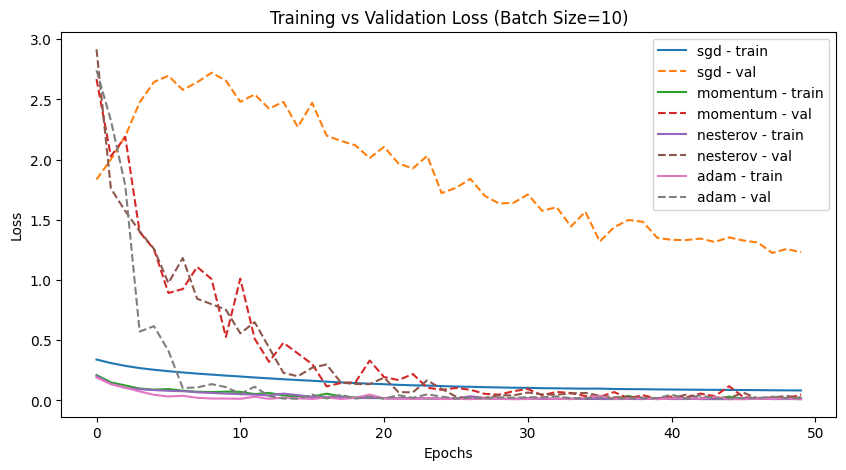

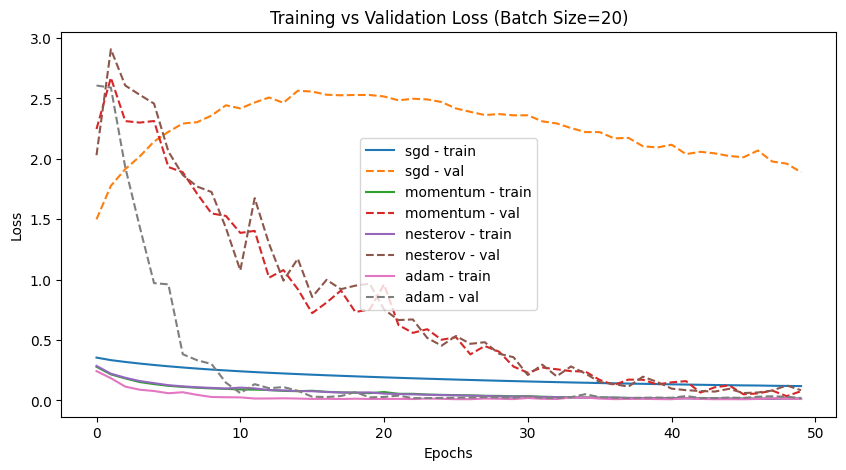

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------- DATA PREPARATION -------------------
np.random.seed(42)
N = 1000
x = np.linspace(0, 2*np.pi, N).reshape(-1, 1)
noise = np.random.normal(0, 0.1, x.shape)
y = np.cos(x) + noise

# Train/Val split
split = int(0.8 * N)
x_train, x_val = x[:split], x[split:]
y_train, y_val = y[:split], y[split:]

# ------------------- ANN ARCHITECTURE -------------------
input_dim = 1
hidden_dim = 20
output_dim = 1

def init_weights():
    W1 = np.random.randn(input_dim, hidden_dim) * 0.1
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) * 0.1
    b2 = np.zeros((1, output_dim))
    return W1, b1, W2, b2

def forward(x, W1, b1, W2, b2):
    z1 = x @ W1 + b1
    a1 = np.tanh(z1)
    z2 = a1 @ W2 + b2
    return z1, a1, z2

def backward(x, y, z1, a1, z2, W2):
    m = len(y)
    dz2 = (z2 - y)
    dW2 = a1.T @ dz2 / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m
    dz1 = (dz2 @ W2.T) * (1 - np.tanh(z1)**2)
    dW1 = x.T @ dz1 / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2

def mse(pred, true):
    return np.mean((pred - true)**2)

# ------------------- OPTIMIZER WRAPPER -------------------
def train(batch_size, optimizer_name):
    W1, b1, W2, b2 = init_weights()
    vW1 = vB1 = vW2 = vB2 = np.zeros(1)

    lr = 0.01
    beta = 0.9
    eps = 1e-8
    mW1 = mB1 = mW2 = mB2 = 0
    vW1 = vB1 = vW2 = vB2 = 0

    train_losses, val_losses = [], []

    for epoch in range(50):
        indices = np.random.permutation(len(x_train))
        for i in range(0, len(x_train), batch_size):
            batch = indices[i:i+batch_size]
            xb, yb = x_train[batch], y_train[batch]

            z1, a1, z2 = forward(xb, W1, b1, W2, b2)
            dW1, db1, dW2, db2 = backward(xb, yb, z1, a1, z2, W2)

            # ---- Apply Optimizers ----
            if optimizer_name == "sgd":
                W1 -= lr * dW1; b1 -= lr * db1
                W2 -= lr * dW2; b2 -= lr * db2

            elif optimizer_name == "momentum":
                mW1 = beta*mW1 + lr*dW1; mB1 = beta*mB1 + lr*db1
                mW2 = beta*mW2 + lr*dW2; mB2 = beta*mB2 + lr*db2
                W1 -= mW1; b1 -= mB1; W2 -= mW2; b2 -= mB2

            elif optimizer_name == "nesterov":
                vW1 = beta*vW1 - lr*dW1; vB1 = beta*vB1 - lr*db1
                vW2 = beta*vW2 - lr*dW2; vB2 = beta*vB2 - lr*db2
                W1 += vW1; b1 += vB1; W2 += vW2; b2 += vB2

            elif optimizer_name == "adam":
                mW1 = beta*mW1 + (1-beta)*dW1; mB1 = beta*mB1 + (1-beta)*db1
                mW2 = beta*mW2 + (1-beta)*dW2; mB2 = beta*mB2 + (1-beta)*db2
                vW1 = beta*vW1 + (1-beta)*(dW1**2); vB1 = beta*vB1 + (1-beta)*(db1**2)
                vW2 = beta*vW2 + (1-beta)*(dW2**2); vB2 = beta*vB2 + (1-beta)*(db2**2)
                W1 -= (lr * mW1)/(np.sqrt(vW1)+eps)
                b1 -= (lr * mB1)/(np.sqrt(vB1)+eps)
                W2 -= (lr * mW2)/(np.sqrt(vW2)+eps)
                b2 -= (lr * mB2)/(np.sqrt(vB2)+eps)

        # log losses
        train_losses.append(mse(forward(x_train, W1, b1, W2, b2)[2], y_train))
        val_losses.append(mse(forward(x_val, W1, b1, W2, b2)[2], y_val))

    return train_losses, val_losses

# ------------------- RUN + PLOT -------------------
optimizers = ["sgd", "momentum", "nesterov", "adam"]

for batch_size in [10, 20]:
    plt.figure(figsize=(10,5))
    for opt in optimizers:
        tr, va = train(batch_size, opt)
        plt.plot(tr, label=f"{opt} - train")
        plt.plot(va, label=f"{opt} - val", linestyle="--")

    plt.title(f"Training vs Validation Loss (Batch Size={batch_size})")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


Observations:

1.Adem is the best because of it's stable convergence.

2.SGD and SGD mometum the latter has best convergence ,but the disadvantage is it noisy in the case of batch size of 10.

3.SGD covergnece slowly and has less noisy when compared to batch size 20




Training with hidden size 10 (ReLU-ReLU):
Epoch 10, Train Loss: 1.476765, Val Loss: 1.420595
Epoch 20, Train Loss: 1.463673, Val Loss: 1.406478
Epoch 30, Train Loss: 1.454632, Val Loss: 1.397489
Epoch 40, Train Loss: 1.447776, Val Loss: 1.389826
Epoch 50, Train Loss: 1.441500, Val Loss: 1.383898
Final Train Loss (ReLU-ReLU): 1.441500, Final Val Loss (ReLU-ReLU): 1.383898

Training with hidden size 10 (Sigmoid-Sigmoid):
Epoch 10, Train Loss: 1.533990, Val Loss: 1.491618
Epoch 20, Train Loss: 1.505350, Val Loss: 1.449769
Epoch 30, Train Loss: 1.500747, Val Loss: 1.440031
Epoch 40, Train Loss: 1.499626, Val Loss: 1.436419
Epoch 50, Train Loss: 1.499430, Val Loss: 1.434827
Final Train Loss (Sigmoid-Sigmoid): 1.499430, Final Val Loss (Sigmoid-Sigmoid): 1.434827

Training with hidden size 10 (Sigmoid-ReLU):
Epoch 10, Train Loss: 1.495716, Val Loss: 1.430317
Epoch 20, Train Loss: 1.493805, Val Loss: 1.428765
Epoch 30, Train Loss: 1.492016, Val Loss: 1.427268
Epoch 40, Train Loss: 1.490220, V

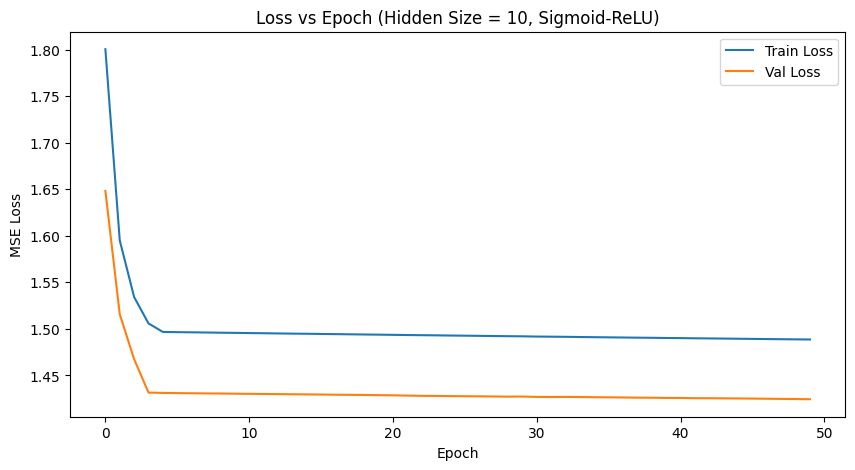


Training with hidden size 15 (Sigmoid-ReLU):
Epoch 10, Train Loss: 1.475225, Val Loss: 1.409072
Epoch 20, Train Loss: 1.453909, Val Loss: 1.390718
Epoch 30, Train Loss: 1.438898, Val Loss: 1.377878
Epoch 40, Train Loss: 1.428091, Val Loss: 1.368766
Epoch 50, Train Loss: 1.419955, Val Loss: 1.362314
Final Train Loss (Sigmoid-ReLU): 1.419955, Final Val Loss (Sigmoid-ReLU): 1.362314


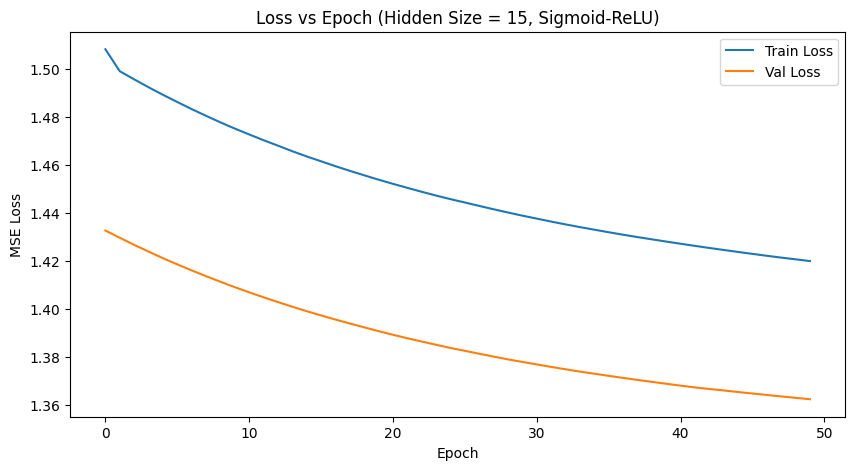


Training with ReLU-ReLU (Hidden Size 5):
Epoch 10, Train Loss: 1.508554, Val Loss: 1.440048
Epoch 20, Train Loss: 1.508554, Val Loss: 1.440048
Epoch 30, Train Loss: 1.508554, Val Loss: 1.440048
Epoch 40, Train Loss: 1.508554, Val Loss: 1.440048
Epoch 50, Train Loss: 1.508554, Val Loss: 1.440048
Final Train Loss (ReLU-ReLU): 1.508554, Final Val Loss (ReLU-ReLU): 1.440048


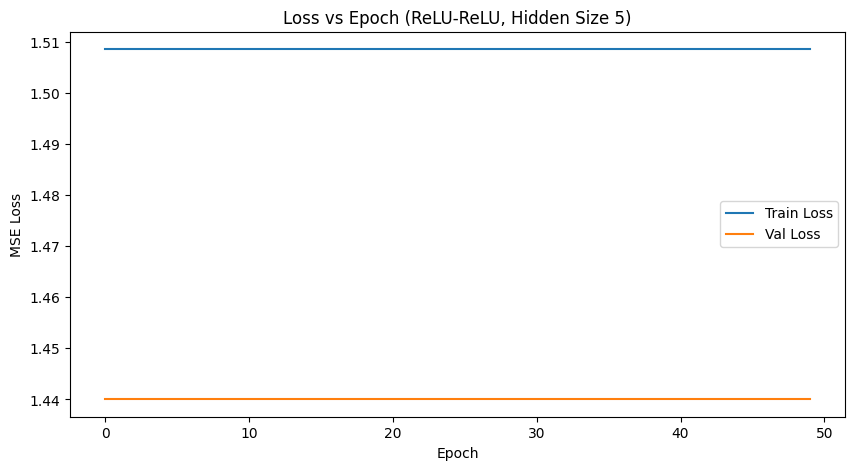


Training with Sigmoid-Sigmoid (Hidden Size 5):
Epoch 10, Train Loss: 1.519916, Val Loss: 1.472132
Epoch 20, Train Loss: 1.502386, Val Loss: 1.445459
Epoch 30, Train Loss: 1.499002, Val Loss: 1.438009
Epoch 40, Train Loss: 1.498534, Val Loss: 1.435367
Epoch 50, Train Loss: 1.498847, Val Loss: 1.434376
Final Train Loss (Sigmoid-Sigmoid): 1.498847, Final Val Loss (Sigmoid-Sigmoid): 1.434376


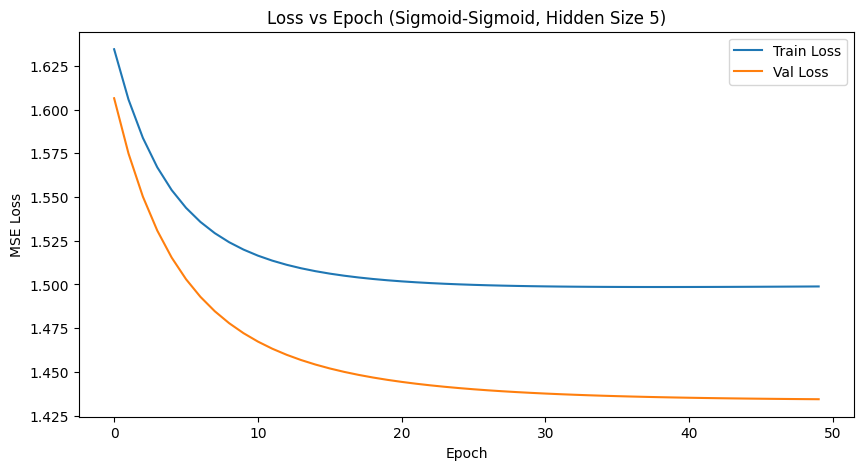

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data Generation
def generate_data(n_points=1000, noise_std=1.0, seed=42):
    rng = np.random.default_rng(seed)
    x = np.linspace(0.0, 2 * np.pi, n_points).reshape(-1, 1)
    y_true = np.cos(x)
    eps = rng.normal(0.0, noise_std, size=(n_points, 1))
    y_noise = y_true + eps
    return x, y_true, y_noise

# Train/Validation Split
def train_val_split(x, y, train_ratio=0.8, seed=42):
    rng = np.random.default_rng(seed)
    n = x.shape[0]
    idx = np.arange(n)
    rng.shuffle(idx)
    x_shuf, y_shuf = x[idx], y[idx]
    split_idx = int(train_ratio * n)
    return (x_shuf[:split_idx], y_shuf[:split_idx]), (x_shuf[split_idx:], y_shuf[split_idx:])

# Batch Iterator
def batch_iter(X, y, batch_size, shuffle=True, seed=123):
    n = X.shape[0]
    indices = np.arange(n)
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_idx = indices[start:end]
        yield X[batch_idx], y[batch_idx]

# Activations
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def relu(z):
    return np.maximum(0.0, z)

# Parameter Initialization
def init_params(input_dim=1, hidden_dim=5, output_dim=1, seed=0):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0.0, 1.0 / np.sqrt(input_dim), size=(input_dim, hidden_dim))
    b1 = np.zeros((1, hidden_dim))
    W2 = rng.normal(0.0, 1.0 / np.sqrt(hidden_dim), size=(hidden_dim, output_dim))
    b2 = np.zeros((1, output_dim))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

# Training Function
def train_model(X_train, y_train, X_val, y_val, params, batch_size=50, epochs=50, learning_rate=0.01, act_hidden=sigmoid, act_output=relu):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        train_loss = 0
        batches = list(batch_iter(X_train, y_train, batch_size, shuffle=True))
        for X_batch, y_batch in batches:
            Z1 = X_batch @ params["W1"] + params["b1"]
            A1 = act_hidden(Z1)
            Z2 = A1 @ params["W2"] + params["b2"]
            y_pred = act_output(Z2)
            m = X_batch.shape[0]
            delta2 = y_pred - y_batch
            if act_output == relu:
                delta2[y_pred <= 0] = 0  # ReLU derivative
            dW2 = (A1.T @ delta2) / m
            db2 = np.mean(delta2, axis=0, keepdims=True)
            delta1 = (delta2 @ params["W2"].T) * (act_hidden(Z1) * (1 - act_hidden(Z1)) if act_hidden == sigmoid else (Z1 > 0).astype(float))
            dW1 = (X_batch.T @ delta1) / m
            db1 = np.mean(delta1, axis=0, keepdims=True)
            params["W1"] -= learning_rate * dW1
            params["b1"] -= learning_rate * db1
            params["W2"] -= learning_rate * dW2
            params["b2"] -= learning_rate * db2
            train_loss += mse(y_batch, y_pred) * m
        train_loss /= len(X_train)
        y_pred_val = forward_batch(X_val, params, act_hidden, act_output)
        val_loss = mse(y_val, y_pred_val)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    return train_losses, val_losses

# Forward Pass
def forward_batch(X, params, act_hidden=sigmoid, act_output=relu):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = act_hidden(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    Y_hat = act_output(Z2)
    return Y_hat

# MSE Loss
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Main Execution
def main():
    # Data Preparation
    x, y_true, y_noise = generate_data(n_points=1000, noise_std=1.0, seed=42)
    (X_train, y_train), (X_val, y_val) = train_val_split(x, y_noise, train_ratio=0.8, seed=42)

    # Experiment with hidden layer size 10 (additional ReLU-ReLU and Sigmoid-Sigmoid)
    hidden_size = 10
    print(f"\nTraining with hidden size {hidden_size} (ReLU-ReLU):")
    params_relu_relu = init_params(input_dim=1, hidden_dim=hidden_size, output_dim=1, seed=42)
    train_losses_relu_relu, val_losses_relu_relu = train_model(X_train, y_train, X_val, y_val, params_relu_relu, batch_size=50, epochs=50, act_hidden=relu, act_output=relu)
    final_train_loss_relu_relu = train_losses_relu_relu[-1]
    final_val_loss_relu_relu = val_losses_relu_relu[-1]
    print(f"Final Train Loss (ReLU-ReLU): {final_train_loss_relu_relu:.6f}, Final Val Loss (ReLU-ReLU): {final_val_loss_relu_relu:.6f}")

    print(f"\nTraining with hidden size {hidden_size} (Sigmoid-Sigmoid):")
    params_sig_sig = init_params(input_dim=1, hidden_dim=hidden_size, output_dim=1, seed=42)
    train_losses_sig_sig, val_losses_sig_sig = train_model(X_train, y_train, X_val, y_val, params_sig_sig, batch_size=50, epochs=50, act_hidden=sigmoid, act_output=sigmoid)
    final_train_loss_sig_sig = train_losses_sig_sig[-1]
    final_val_loss_sig_sig = val_losses_sig_sig[-1]
    print(f"Final Train Loss (Sigmoid-Sigmoid): {final_train_loss_sig_sig:.6f}, Final Val Loss (Sigmoid-Sigmoid): {final_val_loss_sig_sig:.6f}")

    # Experiment with hidden layer sizes 10 and 15 (default Sigmoid-ReLU)
    hidden_sizes = [10, 15]
    for hidden_size in hidden_sizes:
        print(f"\nTraining with hidden size {hidden_size} (Sigmoid-ReLU):")
        params = init_params(input_dim=1, hidden_dim=hidden_size, output_dim=1, seed=42)
        train_losses, val_losses = train_model(X_train, y_train, X_val, y_val, params, batch_size=50, epochs=50)
        final_train_loss = train_losses[-1]
        final_val_loss = val_losses[-1]
        print(f"Final Train Loss (Sigmoid-ReLU): {final_train_loss:.6f}, Final Val Loss (Sigmoid-ReLU): {final_val_loss:.6f}")
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label="Train Loss")
        plt.plot(val_losses, label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"Loss vs Epoch (Hidden Size = {hidden_size}, Sigmoid-ReLU)")
        plt.legend()
        plt.show()

    # Experiment with other activation combinations for hidden size 5
    activation_configs = [
        (relu, relu, "ReLU-ReLU"),
        (sigmoid, sigmoid, "Sigmoid-Sigmoid")
    ]
    for act_hidden, act_output, config_name in activation_configs:
        print(f"\nTraining with {config_name} (Hidden Size 5):")
        params = init_params(input_dim=1, hidden_dim=5, output_dim=1, seed=42)
        train_losses, val_losses = train_model(X_train, y_train, X_val, y_val, params, batch_size=50, epochs=50, act_hidden=act_hidden, act_output=act_output)
        final_train_loss = train_losses[-1]
        final_val_loss = val_losses[-1]
        print(f"Final Train Loss ({config_name}): {final_train_loss:.6f}, Final Val Loss ({config_name}): {final_val_loss:.6f}")
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label="Train Loss")
        plt.plot(val_losses, label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"Loss vs Epoch ({config_name}, Hidden Size 5)")
        plt.legend()
        plt.show()

if __name__ == "__main__":
    main()

1. RELu have faster convergence and it also avoids the problem of vanishing gradients.

2. For lower values of hidden sizes, ReLU works better but it is vice versa in the case of sigmoid functions.

3. For the overall solution, ReLU works the best when compared to sigmoid.